# Prognozowanie szeregu czasowego w Pythonie

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

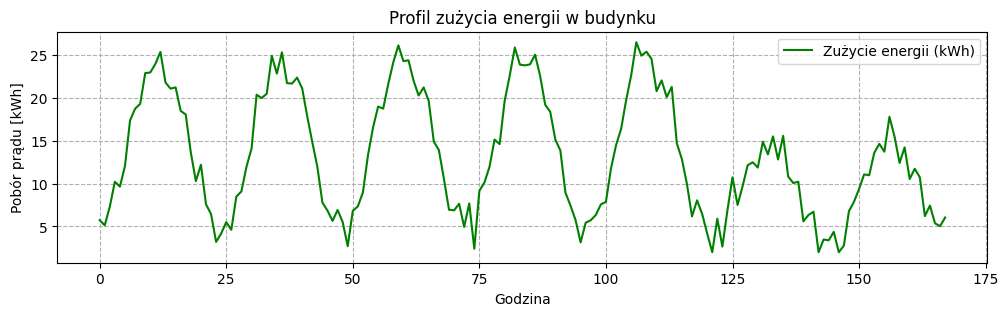

In [12]:
def generate_building_energy_data(n_days=60, noise=2.0):

    np.random.seed(42)
    total_hours = n_days * 24
    time_steps = np.arange(total_hours)

    y = []
    for t in time_steps:
        hour = t % 24
        day_of_week = (t // 24) % 7
        base_load = 15.0
        daily_cycle = 10 * np.sin(2 * np.pi * (hour - 6) / 24)

        if day_of_week >= 5:
            weekend_factor = 0.6
        else:
            weekend_factor = 1.0

        current_load = (base_load + daily_cycle) * weekend_factor
        current_load += np.random.normal(0, noise)
        y.append(max(current_load, 2.0))

    return np.array(y).reshape(-1, 1)

raw_data = generate_building_energy_data(n_days=60, noise=1.5)

plt.figure(figsize=(12, 3))
plt.plot(raw_data[:168], color='green', label='Zużycie energii (kWh)')
plt.title('Profil zużycia energii w budynku')
plt.xlabel('Godzina')
plt.ylabel('Pobór prądu [kWh]')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

Dane treningowe: (1144, 10, 1), Dane walidacyjne: (286, 10, 1)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1025 - mae: 0.2617 - val_loss: 0.0592 - val_mae: 0.2061
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0501 - mae: 0.1918 - val_loss: 0.0403 - val_mae: 0.1729
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0297 - mae: 0.1452 - val_loss: 0.0155 - val_mae: 0.1028
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0101 - mae: 0.0808 - val_loss: 0.0089 - val_mae: 0.0731
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0085 - mae: 0.0745 - val_loss: 0.0082 - val_mae: 0.0711
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0082 - mae: 0.0731 - val_loss: 0.0080 - val_mae: 0.0708
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0079 - mae: 0.0717 - val_loss: 0.0078 - val_mae: 0.0692
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0076 - mae: 0.0706 - val_loss: 0.0076 - val_mae: 0.0686
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0075 - mae:

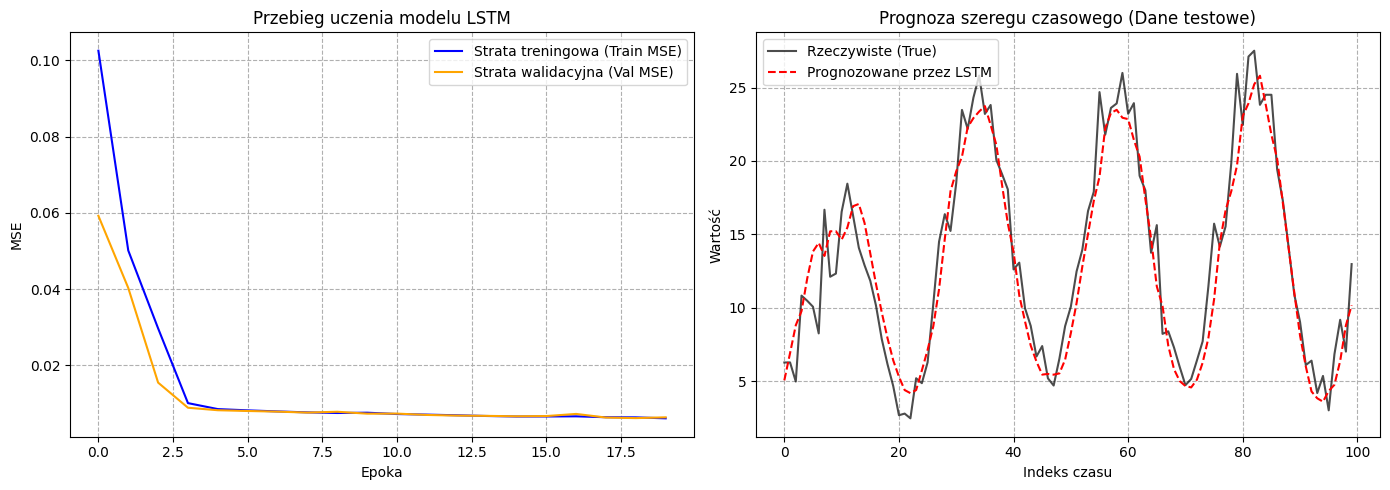

In [13]:
# Normalizacja
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(raw_data)

# Przygotowanie danych sekwencyjnych
def create_dataset(dataset, look_back=10):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 10
X_raw, y_raw = create_dataset(data_scaled, look_back)
X_raw = np.reshape(X_raw, (X_raw.shape[0], X_raw.shape[1], 1))

split_idx = int(0.8 * len(X_raw))

X_train, X_val = X_raw[:split_idx], X_raw[split_idx:]
y_train, y_val = y_raw[:split_idx], y_raw[split_idx:]

print(f"Dane treningowe: {X_train.shape}, Dane walidacyjne: {X_val.shape}")

# Model LSTM
inputs = Input(shape=(look_back, 1))
x = LSTM(50, activation='tanh')(inputs)
outputs = Dense(1, activation='linear')(x)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# Prognozowanie
predicted_scaled = model.predict(X_val)
predicted = scaler.inverse_transform(predicted_scaled)
real = scaler.inverse_transform(y_val.reshape(-1, 1))

# Wykresy
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Strata treningowa (Train MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Strata walidacyjna (Val MSE)', color='orange')
plt.title('Przebieg uczenia modelu LSTM')
plt.xlabel('Epoka')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(real[:100], label='Rzeczywiste (True)', color='black', alpha=0.7)
plt.plot(predicted[:100], label='Prognozowane przez LSTM', color='red', linestyle='--')
plt.title('Prognoza szeregu czasowego (Dane testowe)')
plt.xlabel('Indeks czasu')
plt.ylabel('Wartość')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()




## Przykład: Klasyfikacja sekwencji - wykrywanie anomalii

Kształt danych do modelu LSTM: (1144, 10, 1)
Liczba anomalii w zbiorze treningowym: 137/1144
Liczba anomalii w zbiorze testowym: 28/286


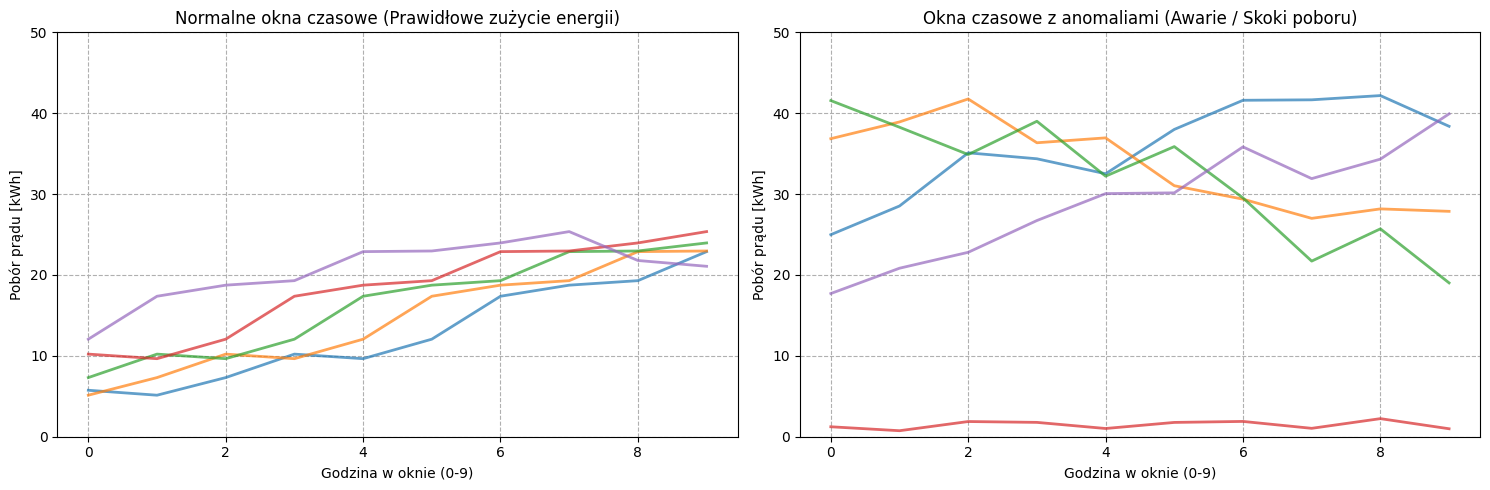

In [18]:
def create_windows_with_anomalies(signal, timesteps=10, anomaly_rate=0.1):
    X = []
    y = []

    for i in range(len(signal) - timesteps):
        window = signal[i : i + timesteps].copy()
        is_anomaly = 0

        if np.random.rand() < anomaly_rate:
            is_anomaly = 1
            if np.random.rand() > 0.5:
                window += np.random.normal(15.0, 2.0, size=window.shape)
            else:
                window = np.random.normal(1.0, 0.5, size=window.shape)
                window = np.clip(window, 0.1, None)

        X.append(window)
        y.append(is_anomaly)

    return np.array(X), np.array(y)

X, y = create_windows_with_anomalies(raw_data, timesteps=10, anomaly_rate=0.12)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kształt danych do modelu LSTM: {X_train.shape}")
print(f"Liczba anomalii w zbiorze treningowym: {int(sum(y_train))}/{len(y_train)}")
print(f"Liczba anomalii w zbiorze testowym: {int(sum(y_test))}/{len(y_test)}")

normal_indices = np.where(y == 0)[0]
anomaly_indices = np.where(y == 1)[0]

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for i in range(5):
    idx = normal_indices[i]
    plt.plot(X[idx].flatten(), label=f'Próbka normalna {i+1}', alpha=0.7, linewidth=2)
plt.title('Normalne okna czasowe (Prawidłowe zużycie energii)')
plt.xlabel('Godzina w oknie (0-9)')
plt.ylabel('Pobór prądu [kWh]')
plt.grid(True, linestyle='--')
plt.ylim(0, 50)


plt.subplot(1, 2, 2)
for i in range(5):
    idx = anomaly_indices[i]
    plt.plot(X[idx].flatten(), label=f'Anomalia {i+1}', alpha=0.7, linewidth=2)
plt.title('Okna czasowe z anomaliami (Awarie / Skoki poboru)')
plt.xlabel('Godzina w oknie (0-9)')
plt.ylabel('Pobór prądu [kWh]')
plt.grid(True, linestyle='--')
plt.ylim(0, 50)

plt.tight_layout()
plt.show()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8794 - loss: 0.4194 - val_accuracy: 0.9021 - val_loss: 0.2667
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8872 - loss: 0.2518 - val_accuracy: 0.9406 - val_loss: 0.1913
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9353 - loss: 0.1961 - val_accuracy: 0.9406 - val_loss: 0.1473
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9353 - loss: 0.1546 - val_accuracy: 0.9406 - val_loss: 0.1294
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9353 - loss: 0.1327 - val_accuracy: 0.9406 - val_loss: 0.1155
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9467 - loss: 0.1179 - val_accuracy: 0.9755 - val_loss: 0.0830
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9545 - loss: 0.1049 - val_accuracy: 0.9790 - val_loss: 0.0740
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9694 - loss: 0.0951 - val_accuracy: 0.9720 - val_los

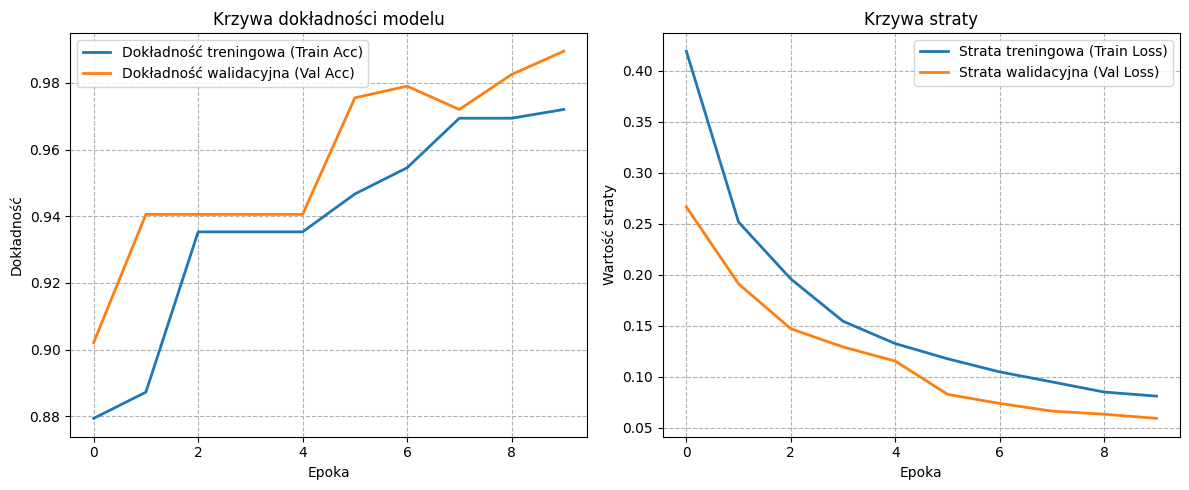

In [21]:

model = Sequential()
model.add(LSTM(32, input_shape=(X.shape[1], 1)))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Ocena modelu
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Dokładnosc: {accuracy:.2f}")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Dokładność treningowa (Train Acc)', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Dokładność walidacyjna (Val Acc)', linewidth=2)
plt.title('Krzywa dokładności modelu')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Strata treningowa (Train Loss)', linewidth=2)
plt.plot(history.history['val_loss'], label='Strata walidacyjna (Val Loss)', linewidth=2)
plt.title('Krzywa straty')
plt.xlabel('Epoka')
plt.ylabel('Wartość straty')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

## Rozpoznawanie wzorców czasowych


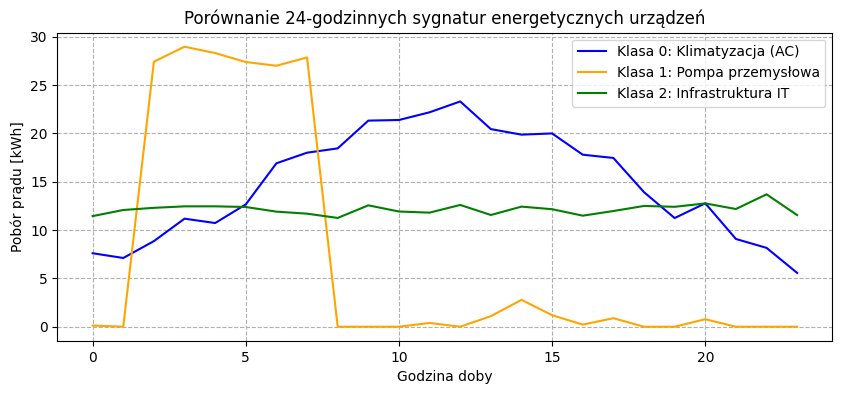

In [22]:
def generate_device_patterns(samples_per_class=500, timesteps=24):
    np.random.seed(42)
    X = []
    y = []
    time = np.arange(timesteps)

    for _ in range(samples_per_class):
        # Klimatyzacja (Profil płynny, dobowy szczyt)
        base_ac = 15.0 + 8 * np.sin(2 * np.pi * (time - 6) / 24)
        noise_ac = np.random.normal(0, 1.2, timesteps)
        X.append(base_ac + noise_ac)
        y.append(0)

        # Pompa przemysłowa ("włącz/wyłącz" - prostokątny)
        base_pump = np.zeros(timesteps)
        start_hour = np.random.randint(2, 8)
        duration = 6
        base_pump[start_hour : start_hour + duration] = 28.0
        noise_pump = np.random.normal(0, 1.0, timesteps)
        signal_pump = base_pump + noise_pump
        signal_pump = np.clip(signal_pump, 0.0, None)

        X.append(signal_pump)
        y.append(1)

        # Infrastruktura IT/Serwery (stały pobór 24h)
        base_it = np.full(timesteps, 12.0)
        noise_it = np.random.normal(0, 0.5, timesteps)
        X.append(base_it + noise_it)
        y.append(2)

    return np.array(X), np.array(y)

X, y = generate_device_patterns(samples_per_class=500, timesteps=24)
X = X.reshape((X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


plt.figure(figsize=(10, 4))
plt.plot(X[0], label='Klasa 0: Klimatyzacja (AC)', color='blue')
plt.plot(X[1], label='Klasa 1: Pompa przemysłowa', color='orange')
plt.plot(X[2], label='Klasa 2: Infrastruktura IT', color='green')
plt.title('Porównanie 24-godzinnych sygnatur energetycznych urządzeń')
plt.xlabel('Godzina doby')
plt.ylabel('Pobór prądu [kWh]')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,091 (66.76 KB)

 Trainable params: 17,091 (66.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9000 - loss: 0.5817 - val_accuracy: 1.0000 - val_loss: 0.2880
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.1196 - val_accuracy: 1.0000 - val_loss: 0.0214
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 0.0054
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - v

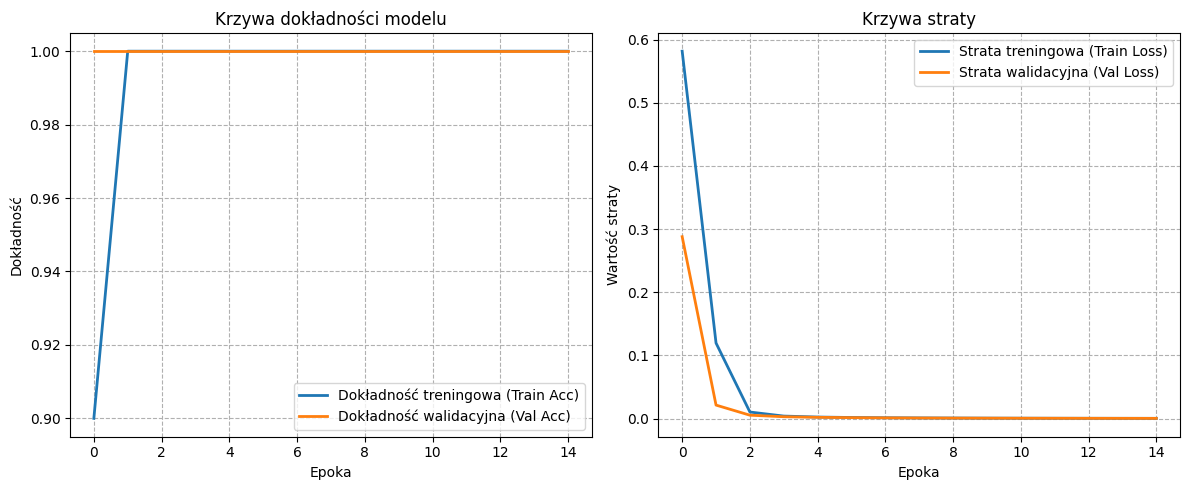

In [23]:
model = Sequential()
model.add(LSTM(64, input_shape=(X.shape[1], 1)))
model.add(Dense(3, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))

# Ocena modelu
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Dokladnosc klasyfikacji aktywnosci: {accuracy:.2f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Dokładność treningowa (Train Acc)', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Dokładność walidacyjna (Val Acc)', linewidth=2)
plt.title('Krzywa dokładności modelu')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Strata treningowa (Train Loss)', linewidth=2)
plt.plot(history.history['val_loss'], label='Strata walidacyjna (Val Loss)', linewidth=2)
plt.title('Krzywa straty')
plt.xlabel('Epoka')
plt.ylabel('Wartość straty')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()